In [25]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
data = pd.read_csv('usa_housing.csv')

In [27]:
df = data.copy()

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [29]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [30]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [31]:
df = df.drop(['Address'],axis=1)

In [32]:
cols = ['Avg. Area Income','Area Population','Price','Avg. Area House Age','Avg. Area Number of Bedrooms']

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler = StandardScaler()

In [35]:
df[cols] = scaler.fit_transform(df[cols])

In [36]:
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,1.028660,-0.296927,7.009188,0.088062,-1.317599,-0.490081
1,1.000808,0.025902,6.730821,-0.722301,0.403999,0.775508
2,-0.684629,-0.112303,8.512727,0.930840,0.072410,-0.490211
3,-0.491499,1.221572,5.586729,-0.584540,-0.186734,0.080843
4,-0.807073,-0.944834,7.839388,0.201513,-0.988387,-1.702518
...,...,...,...,...,...,...
4995,-0.752109,1.869297,6.137356,-0.422467,-1.342732,-0.486795
4996,0.929740,1.030822,6.576763,0.031337,-1.062747,0.709594
4997,-0.487235,1.284470,4.805081,-1.500251,-0.291937,-0.570244
4998,-0.054592,-0.446694,7.130144,1.182053,0.651116,-0.094640


In [37]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5.000000e+03,5.000000e+03,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03
mean,-2.167155e-17,4.263256e-18,6.987792,-2.088996e-16,-3.041123e-16,-1.392664e-16
std,1.000100e+00,1.000100e+00,1.005833,1.000100e+00,1.000100e+00,1.000100e+00
min,-4.765584e+00,-3.361975e+00,3.236194,-1.605598e+00,-3.626413e+00,-3.444336e+00
25%,-6.664724e-01,-6.606490e-01,6.299250,-6.817833e-01,-6.810902e-01,-6.641384e-01
50%,2.075434e-02,-6.852312e-03,7.002902,5.564767e-02,3.616311e-03,1.690042e-03
75%,6.756386e-01,6.794590e-01,7.665871,4.122077e-01,6.748621e-01,6.772856e-01
max,3.670725e+00,3.572745e+00,10.759588,2.041039e+00,3.371219e+00,3.503412e+00


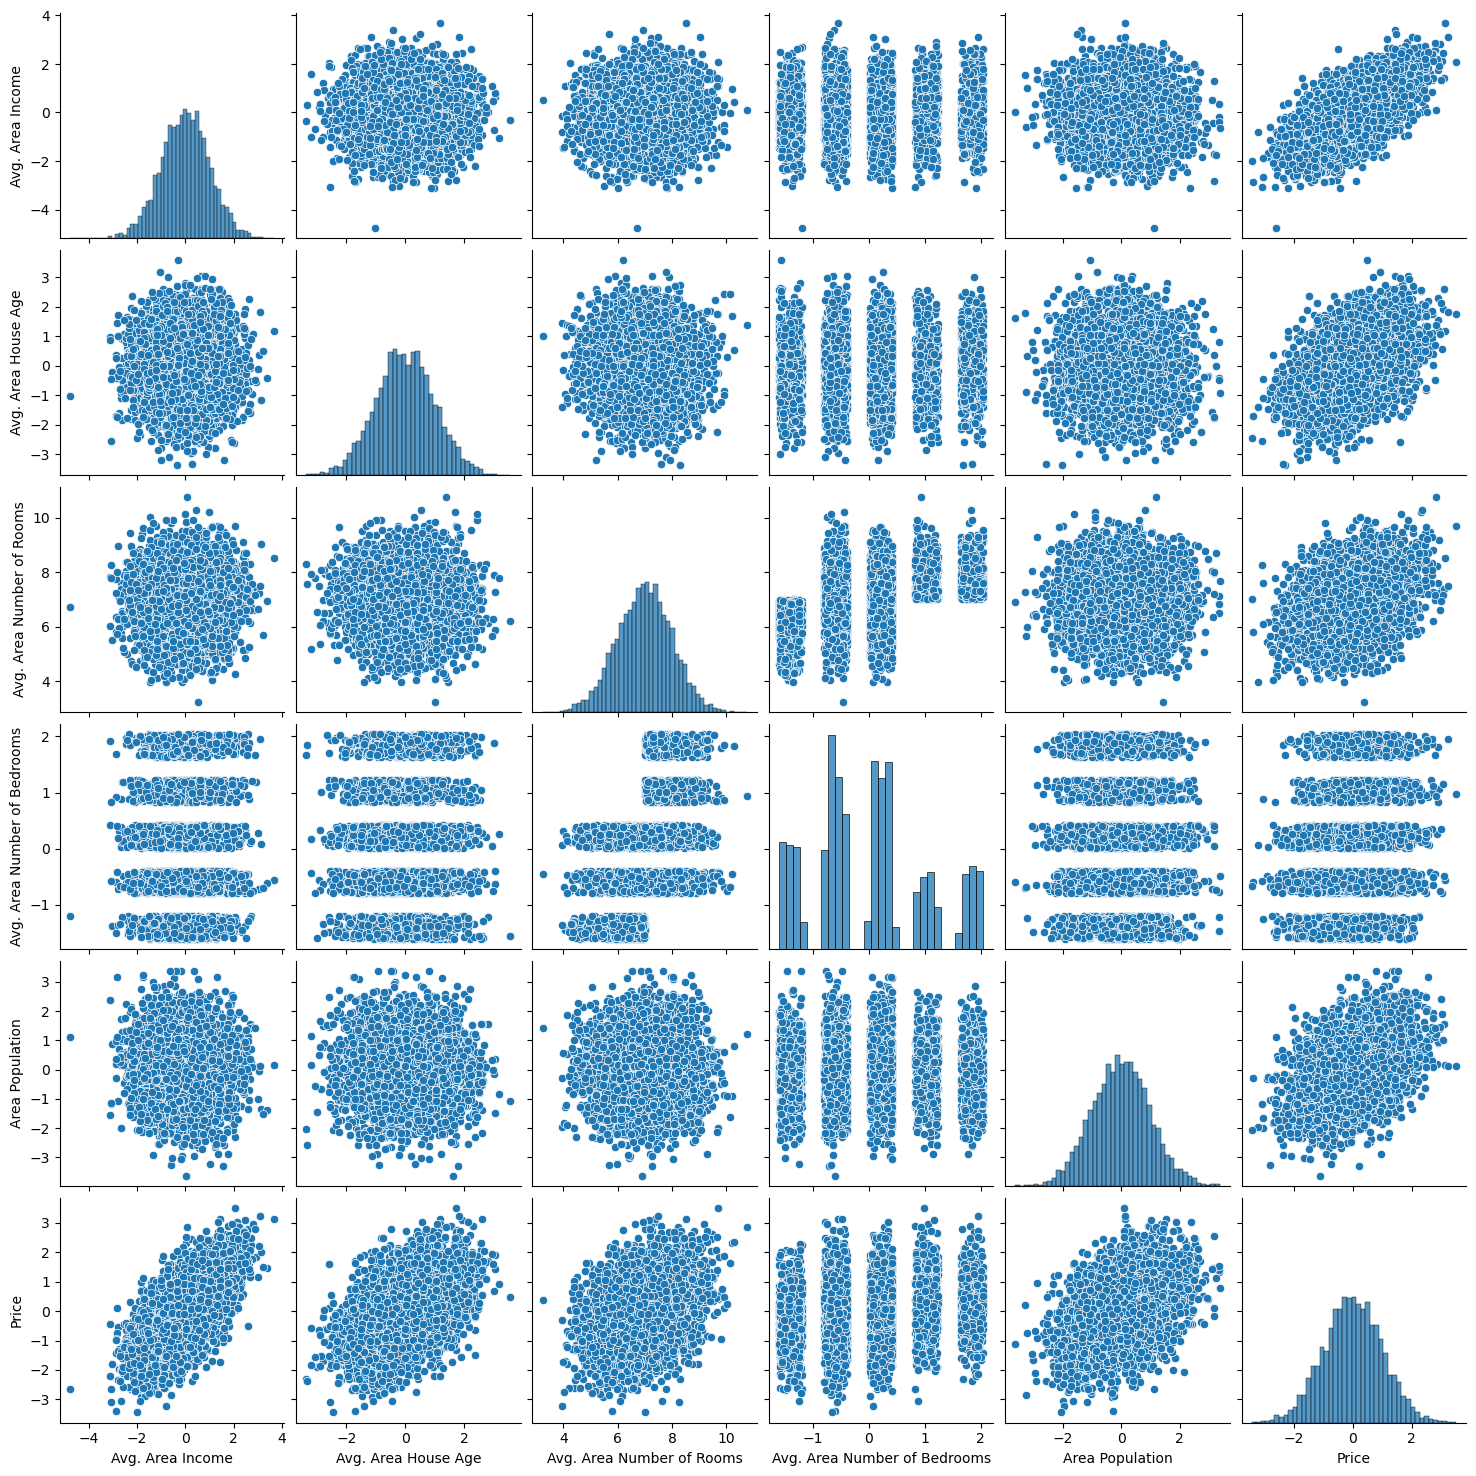

In [38]:
plt.Figure(figsize=(8,6))
sns.pairplot(df)
plt.show()

In [39]:
x = df.drop(['Price'],axis=1)
y = df[['Price']]

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_trian,x_test,y_trian,y_test = train_test_split(x,y,test_size=0.20, random_state=44,shuffle= True)

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
reg = LinearRegression()

In [44]:
reg.fit(x_trian,y_trian)

LinearRegression()

In [45]:
y_pred = reg.predict(x_test)

In [46]:
from sklearn.metrics import r2_score

In [47]:
print(r2_score(y_test,y_pred))

0.9201240205763173
